# MLOps Showcase — Pré-processamento e Feature Engineering
Preparando os dados para o modelo de detecção de anomalias

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

DATA_RAW = '../data/raw/realAWSCloudwatch/realAWSCloudwatch/'
DATA_PROCESSED = '../data/processed/'
DATA_FEATURES = '../data/features/'

os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(DATA_FEATURES, exist_ok=True)
print('Libs carregadas!')

Libs carregadas!


In [44]:
def carregar_e_normalizar(filepath):
    df = pd.read_csv(filepath, parse_dates=['timestamp'])
    df.set_index('timestamp', inplace=True)
    df.sort_index(inplace=True)
    df['arquivo'] = os.path.basename(filepath)
    df['metrica'] = os.path.basename(filepath).replace('.csv', '')
    return df

arquivos = glob.glob(DATA_RAW + '*.csv')
dfs = [carregar_e_normalizar(f) for f in arquivos]
df_raw = pd.concat(dfs)
print(f'Total de registros: {len(df_raw)}')
print(f'Métricas: {df_raw["metrica"].nunique()}')
df_raw.head()

Total de registros: 67740
Métricas: 17


,value,arquivo,metrica
timestamp,,,
2014-02-14 14:27:00,51.846,ec2_cpu_utilization_5f5533.csv,ec2_cpu_utilization_5f5533
2014-02-14 14:32:00,44.508,ec2_cpu_utilization_5f5533.csv,ec2_cpu_utilization_5f5533
2014-02-14 14:37:00,41.244,ec2_cpu_utilization_5f5533.csv,ec2_cpu_utilization_5f5533
2014-02-14 14:42:00,48.568,ec2_cpu_utilization_5f5533.csv,ec2_cpu_utilization_5f5533
2014-02-14 14:47:00,46.714,ec2_cpu_utilization_5f5533.csv,ec2_cpu_utilization_5f5533


In [45]:
def criar_features(df):
    d = df[['value']].copy()
    d['rolling_mean_12'] = d['value'].rolling(12).mean()
    d['rolling_std_12']  = d['value'].rolling(12).std()
    d['rolling_mean_24'] = d['value'].rolling(24).mean()
    d['rolling_std_24']  = d['value'].rolling(24).std()
    d['diff_1']          = d['value'].diff(1)
    d['diff_12']         = d['value'].diff(12)
    d['hora']            = d.index.hour
    d['dia_semana']      = d.index.dayofweek
    mean = d['value'].mean()
    std  = d['value'].std()
    d['zscore']          = (d['value'] - mean) / (std + 1e-9)
    d['anomalia_zscore'] = (d['zscore'].abs() > 3).astype(int)
    return d

resultados = []
for metrica, grupo in df_raw.groupby('metrica'):
    features = criar_features(grupo)
    features['metrica'] = metrica
    resultados.append(features)

df_features = pd.concat(resultados)
df_features.dropna(inplace=True)
print(f'Features criadas: {df_features.shape}')
print(f'Anomalias detectadas (zscore): {df_features["anomalia_zscore"].sum()}')
df_features.head()

Features criadas: (67349, 12)
Anomalias detectadas (zscore): 905


,value,rolling_mean_12,rolling_std_12,rolling_mean_24,rolling_std_24,diff_1,diff_12,hora,dia_semana,zscore,anomalia_zscore,metrica
timestamp,,,,,,,,,,,,
2014-02-14 16:25:00,0.066,0.128167,0.034656,0.125250,0.030244,-0.068,0.000,16,4,-0.636022,0,ec2_cpu_utilization_24ae8d
2014-02-14 16:30:00,0.134,0.128333,0.034681,0.125333,0.030266,0.068,0.002,16,4,0.081180,0,ec2_cpu_utilization_24ae8d
2014-02-14 16:35:00,0.134,0.122667,0.026026,0.125333,0.030266,0.000,-0.068,16,4,0.081180,0,ec2_cpu_utilization_24ae8d
2014-02-14 16:40:00,0.066,0.122500,0.026411,0.122500,0.032519,-0.068,-0.002,16,4,-0.636022,0,ec2_cpu_utilization_24ae8d
2014-02-14 16:45:00,0.134,0.122500,0.026411,0.122500,0.032519,0.068,0.000,16,4,0.081180,0,ec2_cpu_utilization_24ae8d


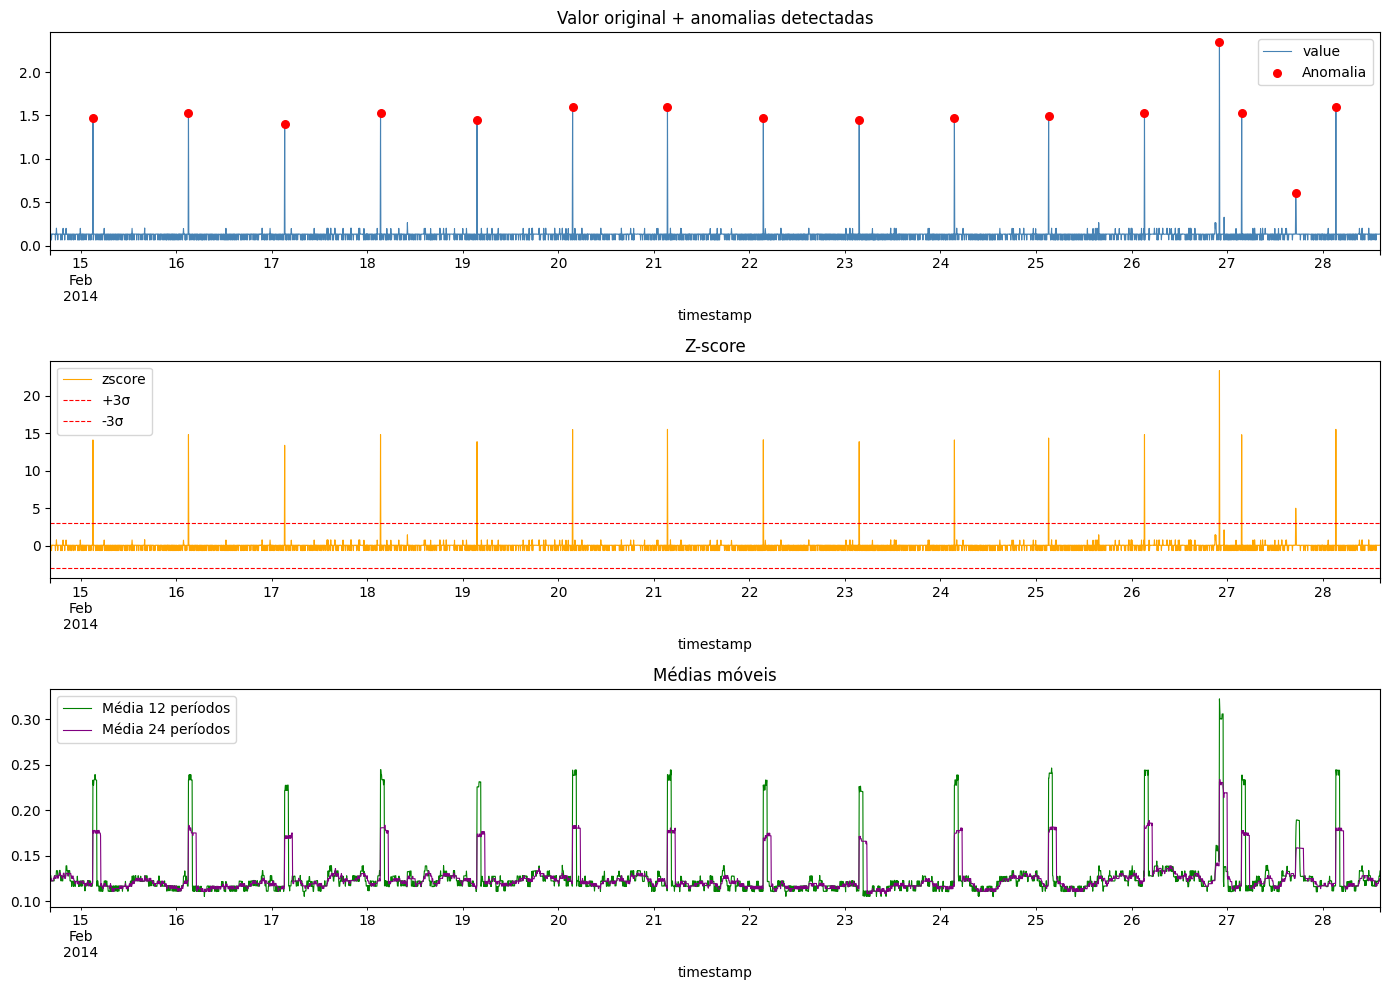

Gráfico salvo!


In [46]:
metrica_exemplo = 'ec2_cpu_utilization_24ae8d'
df_ex = df_features[df_features['metrica'] == metrica_exemplo]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

df_ex['value'].plot(ax=axes[0], color='steelblue', linewidth=0.8)
anomalias = df_ex[df_ex['anomalia_zscore'] == 1]
axes[0].scatter(anomalias.index, anomalias['value'], color='red', s=30, zorder=5, label='Anomalia')
axes[0].set_title('Valor original + anomalias detectadas')
axes[0].legend()

df_ex['zscore'].plot(ax=axes[1], color='orange', linewidth=0.8)
axes[1].axhline(3,  color='red', linestyle='--', linewidth=0.8, label='+3σ')
axes[1].axhline(-3, color='red', linestyle='--', linewidth=0.8, label='-3σ')
axes[1].set_title('Z-score')
axes[1].legend()

df_ex['rolling_mean_12'].plot(ax=axes[2], color='green', linewidth=0.8, label='Média 12 períodos')
df_ex['rolling_mean_24'].plot(ax=axes[2], color='purple', linewidth=0.8, label='Média 24 períodos')
axes[2].set_title('Médias móveis')
axes[2].legend()

plt.tight_layout()
plt.savefig(DATA_PROCESSED + 'features_cpu_utilization.png', dpi=150)
plt.show()
print('Gráfico salvo!')

In [47]:
output_path = DATA_FEATURES + 'features_cloudwatch.csv'
df_features.to_csv(output_path)
print(f'Features salvas em: {output_path}')
print(f'Shape final: {df_features.shape}')
print(f'Colunas: {list(df_features.columns)}')

Features salvas em: ../data/features/features_cloudwatch.csv
Shape final: (67349, 12)
Colunas: ['value', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_24', 'rolling_std_24', 'diff_1', 'diff_12', 'hora', 'dia_semana', 'zscore', 'anomalia_zscore', 'metrica']
